In [42]:
!pip install tensorflow scikeras scikit-learn pandas numpy matplotlib


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [44]:
df=pd.read_csv('/content/Alphabets_data.csv')
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [45]:
df.shape

(20000, 17)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [47]:
df.isna().sum()

,0
letter,0
xbox,0
ybox,0
width,0
height,0
onpix,0
xbar,0
ybar,0
x2bar,0
y2bar,0


In [48]:
df.duplicated().sum()

np.int64(1332)

In [49]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
# Separate features (X) and target (y)
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [52]:
le = LabelEncoder()
y = le.fit_transform(y)

In [53]:
# Normalize feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [54]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((14934, 16), (3734, 16), (14934,), (3734,))

In [55]:
def create_model(neurons=64, activation='relu', learning_rate=0.001, dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(neurons, input_dim=X_train.shape[1], activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(neurons//2, activation=activation))
    model.add(Dense(len(np.unique(y)), activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [62]:
basic_model = create_model()
history = basic_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate base model
y_pred_basic = np.argmax(basic_model.predict(X_test), axis=1)
print("\n--- Basic ANN Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_basic))
print("\n", classification_report(y_test, y_pred_basic))


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1126 - loss: 3.4816 - val_accuracy: 0.5162 - val_loss: 1.8078
Epoch 2/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4403 - loss: 1.8456 - val_accuracy: 0.6408 - val_loss: 1.2648
Epoch 3/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5816 - loss: 1.3750 - val_accuracy: 0.7004 - val_loss: 1.0501
Epoch 4/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6254 - loss: 1.2154 - val_accuracy: 0.7392 - val_loss: 0.9275
Epoch 5/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6575 - loss: 1.0987 - val_accuracy: 0.7549 - val_loss: 0.8617
Epoch 6/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6782 - loss: 1.0345 - val_accuracy: 0.7697 - val_loss: 0.8038
Epoch 7/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6949 - loss: 0.9872 - val_accuracy: 0.7703 - val_loss: 0.7607
Epoch 8/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7102 - loss: 0.9208 - val_accuracy: 0.7871 - val_

In [56]:
model = KerasClassifier(
    model=create_model,
    epochs=20,
    batch_size=32,
    verbose=1
)

In [59]:
param_grid = {
    'model__neurons': [64, 128],
    'model__activation': ['relu'],
    'model__dropout_rate': [0.2],
    'batch_size': [32],
    'epochs': [10, 15]   # much faster
}

In [60]:
# Run GridSearchCV with fewer splits
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=2,          # reduce from 3 to 2
    verbose=1,
    n_jobs=1       # avoid Colab memory conflict
)

grid_result = grid.fit(X_train, y_train)

print("\n✅ Best Parameters Found:\n", grid_result.best_params_)
print("\nBest Cross-Validation Accuracy:", grid_result.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0746 - loss: 3.4368
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3469 - loss: 2.1943
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5261 - loss: 1.5948
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5846 - loss: 1.3618
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6077 - loss: 1.2483
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6450 - loss: 1.1637
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6581 - loss: 1.1209
Epoch 8/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6877 - loss: 1.0359
Epoch 9/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6876 - loss: 1.0016
Epoch 10/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7012 - loss: 0.9804
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0683 - loss: 3.4281
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3115 - loss: 2.2623
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4795 - loss: 1.6943
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5645 - loss: 1.4508
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5924 - loss: 1.3283
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6237 - loss: 1.2206
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6395 - loss: 1.1725
Epoch 8/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6589 - loss: 1.1093
Epoch 9/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6872 - loss: 1.0339
Epoch 10/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6830 - loss: 1.0304
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 1/10


...

234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1368 - loss: 3.2961
Epoch 2/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5103 - loss: 1.6289
Epoch 3/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6288 - loss: 1.2544
Epoch 4/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6741 - loss: 1.0659
Epoch 5/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6999 - loss: 1.0055
Epoch 6/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7409 - loss: 0.8532
Epoch 7/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7429 - loss: 0.8220
Epoch 8/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7681 - loss: 0.7560
Epoch 9/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7768 - loss: 0.7114
Epoch 10/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7831 - loss: 0.6761
Epoch 11/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8027 - loss: 0.6483
Epoch 12/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1705 - loss: 3.0233
Epoch 2/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5478 - loss: 1.5025
Epoch 3/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6216 - loss: 1.2379
Epoch 4/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6886 - loss: 1.0243
Epoch 5/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7115 - loss: 0.9410
Epoch 6/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7339 - loss: 0.8456
Epoch 7/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7496 - loss: 0.7825
Epoch 8/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7772 - loss: 0.7248
Epoch 9/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7834 - loss: 0.6918
Epoch 10/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7894 - loss: 0.6602
Epoch 11/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8038 - loss: 0.6213
Epoch 12/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2062 - loss: 3.0297
Epoch 2/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6281 - loss: 1.2613
Epoch 3/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7183 - loss: 0.9454
Epoch 4/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7497 - loss: 0.8067
Epoch 5/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7883 - loss: 0.6982
Epoch 6/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8004 - loss: 0.6368
Epoch 7/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8237 - loss: 0.5816
Epoch 8/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8265 - loss: 0.5414
Epoch 9/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.4948
Epoch 10/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8531 - loss: 0.4702
Epoch 11/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8523 - loss: 0.4455
Epoch 12/15
467/467 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

In [61]:
best_model = grid_result.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       148
           1       0.84      0.92      0.88       144
           2       0.94      0.95      0.94       137
           3       0.93      0.91      0.92       170
           4       0.92      0.88      0.90       152
           5       0.81      0.90      0.85       145
           6       0.88      0.88      0.88       160
           7       0.79      0.82      0.81       137
           8       0.88      0.83      0.85       106
           9       0.96      0.87      0.91       123
          10       0.93      0.88      0.90       160
          11       0.92      0.92      0.92       128
          12       0.92      0.94      0.93       143
          13       0.88      0.86      0.87       135
          14       0.85      0.88      0.87       153
          15       0.98      0.85      0.91       149
          16   

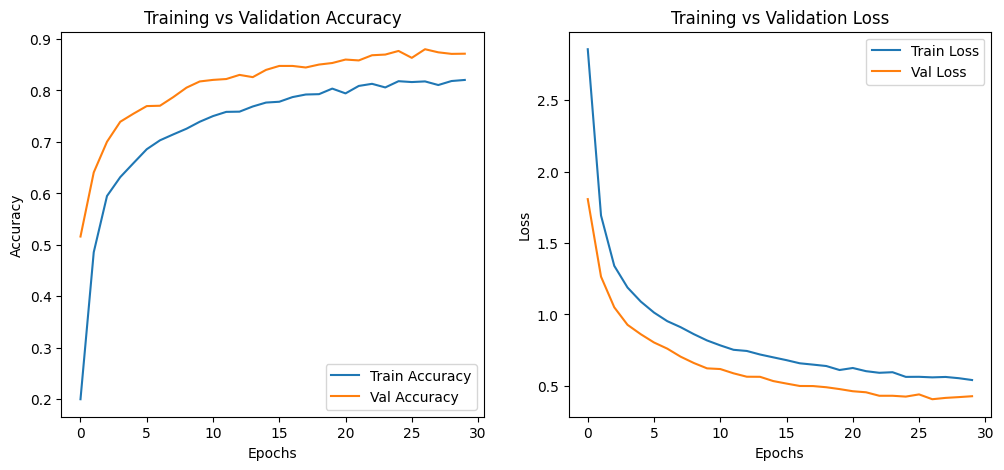

In [63]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()